# 03 LSTM Advanced

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build an **LSTM** (and optionally compare with **GRU**) for a sequence task
- Train on a small text or time-series example and see loss/accuracy
- Understand why we use LSTM instead of SimpleRNN for longer sequences

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lesson 02 "RNNs and LSTMs: Sequence Models Before Transformers" — the gates that made LSTMs usable on language, now examined directly.

---

## 🌍 Real life

**Where is this used?** LSTMs are used in **machine translation**, **speech recognition**, **time series forecasting**, and **text generation** when sequences are long.

**In this notebook we use** an **LSTM** to process **sequences** (e.g. padded text) and produce a classification. We use **LSTM** (instead of SimpleRNN) **because** it has **gates** (forget, input, output) that control what to remember and help avoid **vanishing gradients** on long sequences.

**📌 Covers slide(s):** **12** — LSTM & GRU. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **LSTM:** Long Short-Term Memory. Has a **cell state** (long-term memory) and **hidden state** (output). **Gates** (forget, input, output) decide what to keep, add, and output.
- **GRU:** Gated Recurrent Unit. Simpler than LSTM (fewer gates); often similar performance with fewer parameters.
- **Why LSTM/GRU?** SimpleRNN can have vanishing gradients on long sequences; LSTM/GRU gates control how far back gradients reach. That is a claim about a measurable quantity, and **Step 6 measures it** instead of repeating it — the answer is more interesting than the slogan.
- **We use LSTM** instead of SimpleRNN when sequences are long or when we need better gradient flow.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. We use a small IMDB subset (same as 02_rnn_basics) or a synthetic sequence.

**Dataset:** Real — IMDB (movie reviews, sentiment).

**Outputs:** Training/validation loss and accuracy (with axis labels), test accuracy, optional comparison LSTM vs GRU (one plot).

## Step 1: Imports and load sequence data

In [1]:
# WHAT: load the IMDB movie-review dataset as integer word IDs and pad every review to one length.
# WHY: RNNs need fixed-length numeric sequences - padding/truncating makes all reviews comparable.
import numpy as np
import matplotlib.pyplot as plt

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    keras.utils.set_random_seed(0)   # fixed seed: the curves below are reproducible
    # Keep the 2,000 most common words; pad or truncate each review to exactly maxlen tokens.
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=2000)
    maxlen = 100
    x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen, padding="post", truncating="post")
    x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding="post", truncating="post")
    # Small train/test subsets keep CPU training fast.
    x_train, y_train = x_train[:2000], y_train[:2000]
    x_test, y_test = x_test[:500], y_test[:500]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (2000, 100) Test: (500, 100)


## Step 2: Build LSTM model (we use LSTM instead of SimpleRNN for better long-range dependency)

In [2]:
# WHAT: build an Embedding -> LSTM(64) -> sigmoid classifier for review sentiment.
# WHY: return_sequences=False keeps only the final hidden state - a learned summary of the whole review.
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Input(shape=(maxlen,)),   # declare the input length so summary() can count params
        keras.layers.Embedding(2000, 64),
        keras.layers.LSTM(64, return_sequences=False),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,089 (629.25 KB)

 Trainable params: 161,089 (629.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train the LSTM (12 epochs — enough for the curves to have a shape)

In [3]:
# WHAT: train the LSTM for 12 epochs, one printed line per epoch.
# WHY: two epochs draw a two-point "curve" that cannot show anything. Twelve is a few seconds
#      of CPU time and long enough for the validation curve to turn.
if HAS_TF:
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test),
                        epochs=12, batch_size=64, verbose=2)

Epoch 1/12


32/32 - 1s - 30ms/step - accuracy: 0.5280 - loss: 0.6909 - val_accuracy: 0.5340 - val_loss: 0.6945


Epoch 2/12


32/32 - 0s - 14ms/step - accuracy: 0.6735 - loss: 0.6446 - val_accuracy: 0.6960 - val_loss: 0.6914


Epoch 3/12


...

32/32 - 0s - 14ms/step - accuracy: 0.9180 - loss: 0.2145 - val_accuracy: 0.6860 - val_loss: 0.9855


Epoch 11/12


32/32 - 0s - 14ms/step - accuracy: 0.9190 - loss: 0.2103 - val_accuracy: 0.7460 - val_loss: 0.6138


Epoch 12/12


32/32 - 0s - 14ms/step - accuracy: 0.9500 - loss: 0.1532 - val_accuracy: 0.7600 - val_loss: 0.6219


## Step 3b: The same job with a GRU and with a SimpleRNN

The notebook promised a comparison, so here it is rather than as a suggestion. A **GRU** merges the LSTM's forget and input gates into one update gate and drops the separate cell state, so it has about **three quarters** of the LSTM's recurrent parameters. A **SimpleRNN** has no gates at all — it is the model the whole lesson is arguing against, and it has about **a quarter** of the parameters.

All three get the same data, the same 12 epochs and the same seed, so the curves are comparable.

In [4]:
# WHAT: train a GRU and a SimpleRNN of the same width on the same data.
# WHY: "LSTM instead of SimpleRNN" and "GRU is nearly as good for fewer parameters" are claims.
#      Three curves on one axis test both of them at once.
if HAS_TF:
    def build(recurrent_layer):
        keras.utils.set_random_seed(0)          # same starting point for every architecture
        m = keras.Sequential([
            keras.layers.Input(shape=(maxlen,)),
            keras.layers.Embedding(2000, 64),
            recurrent_layer,
            keras.layers.Dense(1, activation="sigmoid"),
        ])
        m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
        return m

    gru_model = build(keras.layers.GRU(64))
    gru_hist = gru_model.fit(x_train, y_train, validation_data=(x_test, y_test),
                             epochs=12, batch_size=64, verbose=0)
    rnn_model = build(keras.layers.SimpleRNN(64))
    rnn_hist = rnn_model.fit(x_train, y_train, validation_data=(x_test, y_test),
                             epochs=12, batch_size=64, verbose=0)

    n_par = {"LSTM": model.layers[1].count_params(),
             "GRU": gru_model.layers[1].count_params(),
             "SimpleRNN": rnn_model.layers[1].count_params()}
    print("Recurrent-layer parameters:", ", ".join(f"{k} {v:,}" for k, v in n_par.items()))
    print(f"GRU has {n_par['GRU'] / n_par['LSTM']:.0%} of the LSTM's recurrent parameters; "
          f"SimpleRNN has {n_par['SimpleRNN'] / n_par['LSTM']:.0%}.")
    for name, h in [("LSTM", history.history), ("GRU", gru_hist.history), ("SimpleRNN", rnn_hist.history)]:
        print(f"{name:10s} best validation accuracy {max(h['val_accuracy']):.3f} "
              f"(final {h['val_accuracy'][-1]:.3f})")

Recurrent-layer parameters: LSTM 33,024, GRU 24,960, SimpleRNN 8,256
GRU has 76% of the LSTM's recurrent parameters; SimpleRNN has 25%.
LSTM       best validation accuracy 0.776 (final 0.760)
GRU        best validation accuracy 0.720 (final 0.692)
SimpleRNN  best validation accuracy 0.544 (final 0.520)


## Step 4: Plot loss and accuracy

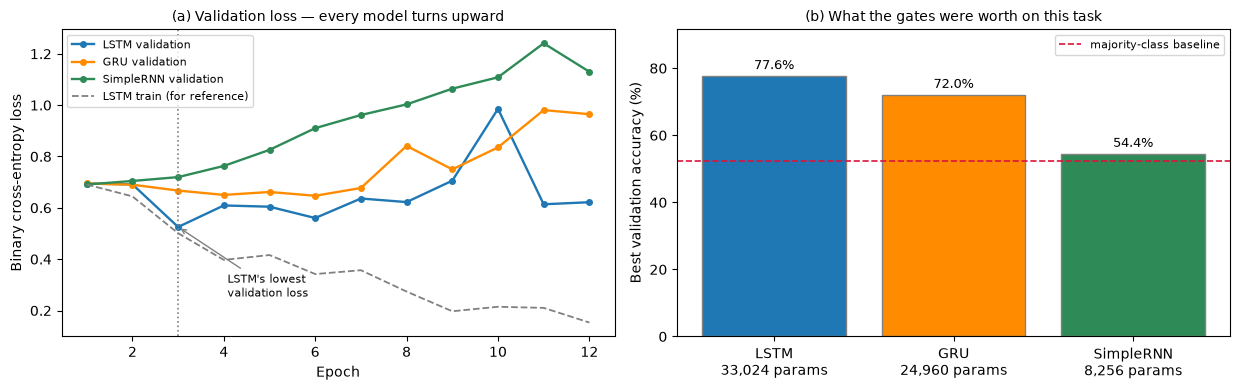

Final-epoch test accuracy - LSTM: 0.7600


In [5]:
# WHAT: validation loss for all three architectures, and their best validation accuracy as bars.
# WHY: the loss panel answers "is it overfitting?"; the bar panel answers "which architecture
#      actually wins here, and what did the extra parameters buy?"
if HAS_TF:
    ep = np.arange(1, len(history.history["loss"]) + 1)
    runs = [("LSTM", history.history, "#1f77b4"),
            ("GRU", gru_hist.history, "darkorange"),
            ("SimpleRNN", rnn_hist.history, "seagreen")]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4))

    for name, h, col in runs:
        ax1.plot(ep, h["val_loss"], "o-", color=col, lw=1.7, ms=4, label=f"{name} validation")
    ax1.plot(ep, history.history["loss"], "--", color="grey", lw=1.3,
             label="LSTM train (for reference)")
    best = int(np.argmin(history.history["val_loss"]))
    ax1.axvline(best + 1, color="grey", ls=":", lw=1.2)
    ax1.annotate("LSTM's lowest\nvalidation loss", xy=(best + 1, history.history["val_loss"][best]),
                 xytext=(0.30, 0.13), textcoords="axes fraction", fontsize=8,
                 arrowprops=dict(arrowstyle="->", color="grey"))
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Binary cross-entropy loss")
    ax1.set_title("(a) Validation loss — every model turns upward", fontsize=10)
    ax1.legend(fontsize=8)

    names = [f"{r[0]}\n{n_par[r[0]]:,} params" for r in runs]
    bestacc = [max(r[1]["val_accuracy"]) * 100 for r in runs]
    bars = ax2.bar(names, bestacc, color=[r[2] for r in runs], edgecolor="grey")
    ax2.bar_label(bars, fmt="%.1f%%", fontsize=9, padding=3)
    ax2.axhline(max(y_test.mean(), 1 - y_test.mean()) * 100, color="crimson", ls="--", lw=1.2,
                label="majority-class baseline")
    ax2.set_ylim(0, max(bestacc) + 14)
    ax2.set_ylabel("Best validation accuracy (%)")
    ax2.set_title("(b) What the gates were worth on this task", fontsize=10)
    ax2.legend(fontsize=8, loc="upper right")
    plt.tight_layout(); plt.show()

    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print("Final-epoch test accuracy - LSTM: %.4f" % acc)

### 👁️ Read the figure

- **(a)** Every one of the three validation curves turns upward, and none of them ever comes back down: with 2,000 training reviews these models start memorising within a handful of epochs. The grey dashed line is the LSTM's *training* loss over the same epochs — still falling while its validation loss climbs. Two lines moving in opposite directions is what overfitting looks like; the dotted vertical marks the epoch you would have stopped at.
- **(b)** The scoreboard, with each model's recurrent-parameter count under its name and the majority-class baseline in red (~52%). The gateless **SimpleRNN lands barely above that line** — on 100-word reviews it is close to useless. The **GRU** saves about a quarter of the LSTM's recurrent parameters and gives up several points of accuracy. The **LSTM** wins.
- Honest scope: one seed, 2,000 training reviews, 12 epochs. That is enough to show the ordering and not enough to publish. Read the gap between SimpleRNN and the other two as the real result — it is far larger than run-to-run noise; the GRU-vs-LSTM gap is smaller and would need several seeds to defend.

## Step 5: Open the gates

Everything above treats the LSTM as a box. The cell below takes the **trained weights out of that box** and re-runs the recurrence by hand in NumPy — one line per equation — so the three gates and the cell state become numbers we can plot.

$$i_t=\sigma(W_i x_t + U_i h_{t-1} + b_i)\quad f_t=\sigma(W_f x_t + U_f h_{t-1} + b_f)\quad o_t=\sigma(W_o x_t + U_o h_{t-1} + b_o)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tanh(W_c x_t + U_c h_{t-1} + b_c) \qquad h_t = o_t \odot \tanh(c_t)$$

The cell checks its own arithmetic against Keras before plotting anything: if the hand-written recurrence does not reproduce Keras's hidden states to floating-point precision, the figure is not to be trusted, and the printed error says so.

Using test review #1 - 100 real words, no padding.
Max |NumPy h_t - Keras h_t| = 4.42e-07   ->  MATCH
Mean gate values over this review - forget 0.73, input 0.52, output 0.52
Per-unit average forget gate ranges from 0.66 to 0.82; 0 of 64 units keep more than 90% of their memory per step.
A cell with f = 0.73 retains 0.046 of a memory after 10 words and 0.0021 after 20. That is this model's effective memory span.


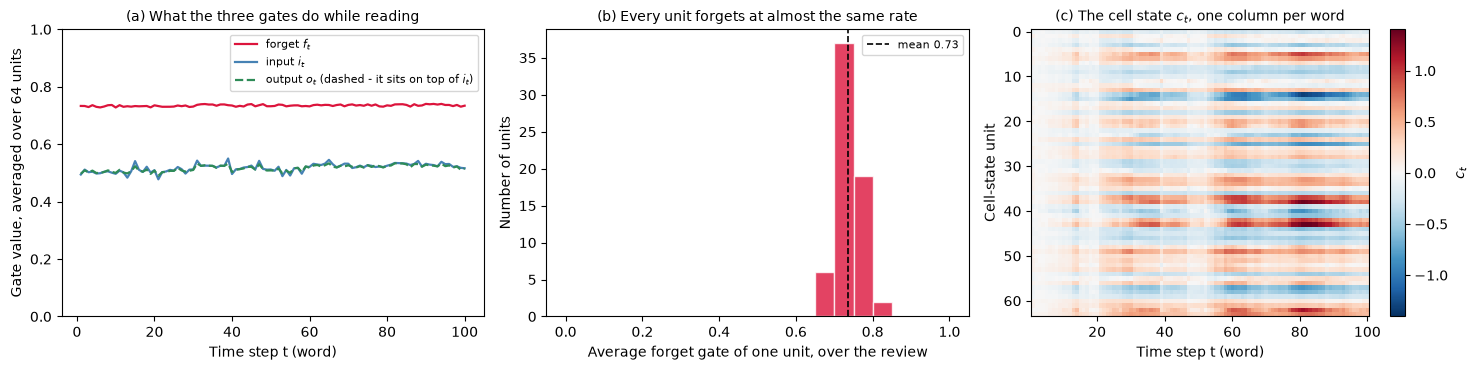

In [6]:
# WHAT: re-run the TRAINED LSTM by hand in NumPy, keeping every gate value at every time step.
# WHY: "gates decide what to remember" is the headline claim of this lesson. Keras hides them,
#      so we take the weights out and compute them ourselves - then plot what they do.
if HAS_TF:
    emb_layer, lstm_layer, dense_layer = model.layers[0], model.layers[1], model.layers[2]
    W, U, b = lstm_layer.get_weights()      # kernel, recurrent kernel, bias
    units = U.shape[0]
    sigmoid = lambda z: 1.0 / (1.0 + np.exp(-z))

    # Pick a review long enough to fill all 100 slots, so every time step below is a real
    # word. On a padded review the gates would just be reacting to filler.
    review = int(np.where((x_test != 0).all(axis=1))[0][0])
    print(f"Using test review #{review} - {maxlen} real words, no padding.")
    E = emb_layer(x_test[review:review + 1]).numpy()[0]      # (maxlen, embed_dim)

    h = np.zeros(units); c = np.zeros(units)
    I, F, O, Cs, Hs = [], [], [], [], []
    for t in range(maxlen):
        z = E[t] @ W + h @ U + b            # Keras packs the four gates in one matrix:
        i = sigmoid(z[:units])              #   input
        f = sigmoid(z[units:2 * units])     #   forget
        g = np.tanh(z[2 * units:3 * units]) #   candidate memory
        o = sigmoid(z[3 * units:])          #   output
        c = f * c + i * g                   # the cell state: keep some, add some
        h = o * np.tanh(c)                  # the hidden state we actually read out
        I.append(i); F.append(f); O.append(o); Cs.append(c); Hs.append(h)
    I, F, O, Cs, Hs = map(np.array, (I, F, O, Cs, Hs))

    # Honesty check: does the hand-written recurrence match Keras exactly?
    probe = keras.layers.LSTM(units, return_sequences=True)
    probe(np.zeros((1, maxlen, W.shape[0]), dtype="float32"))   # build it
    probe.set_weights([W, U, b])
    h_keras = probe(E[None].astype("float32")).numpy()[0]
    err = float(np.abs(h_keras - Hs).max())
    print(f"Max |NumPy h_t - Keras h_t| = {err:.2e}   ->  {'MATCH' if err < 1e-4 else 'MISMATCH - do not trust the plot'}")
    print(f"Mean gate values over this review - forget {F.mean():.2f}, input {I.mean():.2f}, output {O.mean():.2f}")
    per_unit_f = F.mean(axis=0)
    print(f"Per-unit average forget gate ranges from {per_unit_f.min():.2f} to {per_unit_f.max():.2f}; "
          f"{int((per_unit_f > 0.9).sum())} of {units} units keep more than 90% of their memory per step.")
    # If a cell multiplies its contents by f every step, what fraction survives 20 words?
    fbar = float(per_unit_f.mean())
    print(f"A cell with f = {fbar:.2f} retains {fbar**10:.3f} of a memory after 10 words "
          f"and {fbar**20:.4f} after 20. That is this model's effective memory span.")

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

    axes[0].plot(np.arange(1, maxlen + 1), F.mean(1), lw=1.6, color="crimson", label="forget $f_t$")
    axes[0].plot(np.arange(1, maxlen + 1), I.mean(1), lw=1.6, color="steelblue", label="input $i_t$")
    axes[0].plot(np.arange(1, maxlen + 1), O.mean(1), lw=1.6, color="seagreen", ls="--",
                 label="output $o_t$ (dashed - it sits on top of $i_t$)")
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel("Time step t (word)"); axes[0].set_ylabel("Gate value, averaged over 64 units")
    axes[0].set_title("(a) What the three gates do while reading", fontsize=10)
    axes[0].legend(fontsize=8)

    axes[1].hist(per_unit_f, bins=20, range=(0, 1), color="crimson", alpha=0.8, edgecolor="white")
    axes[1].axvline(per_unit_f.mean(), color="black", ls="--", lw=1.2,
                    label=f"mean {per_unit_f.mean():.2f}")
    axes[1].set_xlabel("Average forget gate of one unit, over the review")
    axes[1].set_ylabel("Number of units")
    axes[1].set_title("(b) Every unit forgets at almost the same rate", fontsize=10)
    axes[1].legend(fontsize=8)

    lim = float(np.abs(Cs).max())
    im = axes[2].imshow(Cs.T, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim,
                        interpolation="nearest", extent=[0.5, maxlen + 0.5, units - 0.5, -0.5])
    axes[2].set_xlabel("Time step t (word)"); axes[2].set_ylabel("Cell-state unit")
    axes[2].set_title("(c) The cell state $c_t$, one column per word", fontsize=10)
    fig.colorbar(im, ax=axes[2], label="$c_t$")
    plt.tight_layout(); plt.show()

### 👁️ Read the figure

The printed line above is the first thing to check: the hand-written NumPy recurrence reproduces Keras's hidden states to about 1e-7, so these gate values really are this trained model's gates, not an approximation of them.

- **(a)** The three gates, averaged over the 64 units, at every word of a real 100-word review. The striking thing is how **flat** they are. The forget gate sits at ≈0.73 from the first word to the last; input and output hover at ≈0.5 and lie almost on top of each other (the output line is dashed so you can see both). This trained model does not open and close its gates dramatically as it reads — it settled on a policy and applied it uniformly.
- **(b)** The same forget gates, one number per unit, as a histogram. Every unit is inside a narrow band around 0.73; **not one of the 64 keeps more than 90%** of its memory per step. There is no "hoarder" cell here holding the beginning of the review to the end.
- **What that costs, in words:** a cell that keeps 73% of its contents each step retains about **4.6% of a memory after 10 words and 0.2% after 20**. The printed line gives the exact figures. This model's usable memory is roughly a sentence — not the review.
- **(c)** The cell state itself, one column per word. Note the scale on the colour bar: $c_t$ runs past ±1, because unlike $h_t$ it is never squashed by a tanh. Blocks of colour do last for tens of words — but read that together with (b): with 73% survival per step, those blocks are being **continuously re-driven by incoming words**, not held since the opening line. The picture and the measurement have to be read together, and the measurement is the stricter of the two.

## Step 6: What the gates actually control — measure the gradient horizon

The slogan is "SimpleRNN suffers from vanishing gradients, LSTM gates fix it." Slogans are not measurements. The quantity behind it is concrete: how much does the network's output still depend on the word at position *t*, as *t* moves further back from the end? That is $\lVert \partial\,\text{output}/\partial\,e_t \rVert$, and we can compute it exactly on real reviews.

We measure three networks, all the same width, all sharing one embedding, all **untrained**, so any difference is the recurrence itself:

1. a **SimpleRNN**, whose recurrent matrix Keras initialises to be *orthogonal* (norm-preserving);
2. an **LSTM** with Keras's default forget-gate bias of **+1**, i.e. $f \approx 0.73$ per step;
3. the **same LSTM with the forget-gate bias set to +5**, i.e. $f \approx 0.993$ per step — one number changed, nothing else.

Read the result before you read the slogan.

Forget gate implied by bias +1: f = 0.731 per step  ->  f^100 = 2.48e-14
Forget gate implied by bias +5: f = 0.993 per step  ->  f^100 = 5.11e-01

SimpleRNN (orthogonal init)      gradient falls to 1% after >= 100 words (no decay inside the review)
LSTM, forget bias +1 (default)   gradient falls to 1% after 26 words
LSTM, forget bias +5             gradient falls to 1% after >= 100 words (no decay inside the review)


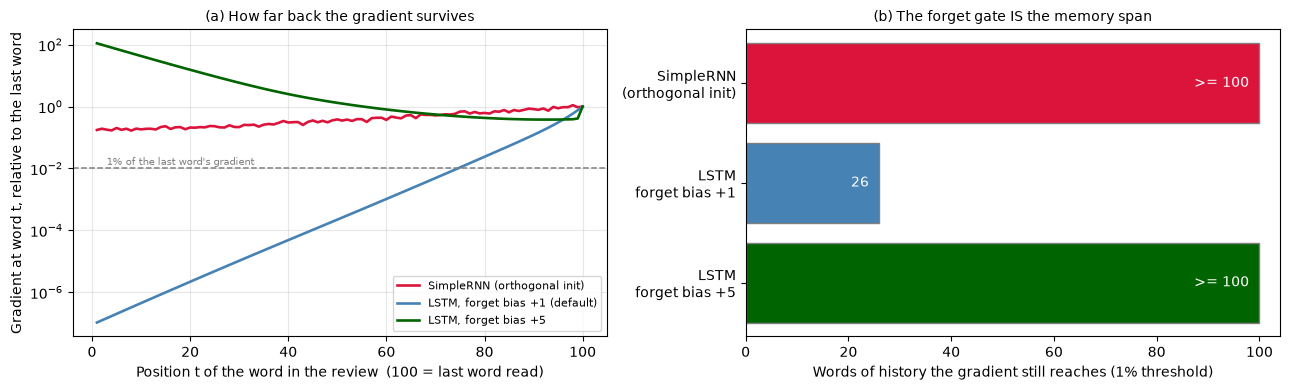

In [7]:
# WHAT: measure how far back a gradient survives in a SimpleRNN and in two LSTMs that differ
#       only in their forget-gate bias.
# WHY: "vanishing gradients" is usually asserted. It is a number. And the number turns out to
#      depend on the FORGET GATE, which is exactly the thing this lesson is about.
if HAS_TF:
    keras.utils.set_random_seed(0)
    shared_emb = keras.layers.Embedding(2000, 64)
    batch = x_test[:64]
    E_batch = shared_emb(batch)                      # identical input for all three networks

    def step_gradient_norms(recurrent_layer):
        """Average over the batch of ||d output / d e_t|| for every time step t."""
        head = keras.layers.Dense(1)
        with tf.GradientTape() as tape:
            tape.watch(E_batch)
            total = tf.reduce_sum(head(recurrent_layer(E_batch)))
        g = tape.gradient(total, E_batch)            # (batch, maxlen, embed_dim)
        return tf.reduce_mean(tf.norm(g, axis=-1), axis=0).numpy()

    keras.utils.set_random_seed(1)
    g_rnn = step_gradient_norms(keras.layers.SimpleRNN(64))

    keras.utils.set_random_seed(1)
    g_lstm = step_gradient_norms(keras.layers.LSTM(64))

    # The same LSTM with one number changed: the forget-gate bias, +1 -> +5.
    keras.utils.set_random_seed(1)
    open_lstm = keras.layers.LSTM(64)
    open_lstm(E_batch[:1])                            # build it so the weights exist
    Wo, Uo, bo = open_lstm.get_weights()
    bo = bo.copy(); bo[64:128] = 5.0                  # slots 64:128 are the forget-gate bias
    open_lstm.set_weights([Wo, Uo, bo])
    g_open = step_gradient_norms(open_lstm)

    sig = lambda z: 1 / (1 + np.exp(-z))
    print(f"Forget gate implied by bias +1: f = {sig(1.0):.3f} per step  ->  f^100 = {sig(1.0)**100:.2e}")
    print(f"Forget gate implied by bias +5: f = {sig(5.0):.3f} per step  ->  f^100 = {sig(5.0)**100:.2e}")

    def horizon(g, frac=0.01):
        """How many words back before the gradient drops to `frac` of its value at the last word."""
        for d in range(len(g)):
            if g[-1 - d] < frac * g[-1]:
                return d
        return len(g)                                  # never drops that far inside the sequence

    curves = [("SimpleRNN (orthogonal init)", g_rnn, "crimson"),
              ("LSTM, forget bias +1 (default)", g_lstm, "steelblue"),
              ("LSTM, forget bias +5", g_open, "darkgreen")]
    print()
    for name, g, _ in curves:
        h = horizon(g)
        span = f"{h} words" if h < len(g) else f">= {len(g)} words (no decay inside the review)"
        print(f"{name:32s} gradient falls to 1% after {span}")

    steps = np.arange(1, maxlen + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    for name, g, col in curves:
        ax1.semilogy(steps, g / g[-1], color=col, lw=1.9, label=name)
    ax1.axhline(0.01, color="grey", ls="--", lw=1.1)
    ax1.text(3, 0.013, "1% of the last word's gradient", fontsize=7.5, color="grey")
    ax1.set_xlabel("Position t of the word in the review  (100 = last word read)")
    ax1.set_ylabel("Gradient at word t, relative to the last word")
    ax1.set_title("(a) How far back the gradient survives", fontsize=10)
    ax1.legend(fontsize=8, loc="lower right")
    ax1.grid(alpha=0.3, which="both")

    hs = [min(horizon(g), maxlen) for _, g, _ in curves]
    labels = ["SimpleRNN\n(orthogonal init)", "LSTM\nforget bias +1", "LSTM\nforget bias +5"]
    bars = ax2.barh(labels, hs, color=[c for _, _, c in curves], edgecolor="grey")
    for bar, h in zip(bars, hs):
        txt = f"{h}" if h < maxlen else f">= {maxlen}"
        ax2.text(bar.get_width() - 2, bar.get_y() + bar.get_height() / 2, txt,
                 va="center", ha="right", color="white", fontsize=10)
    ax2.set_xlim(0, maxlen + 4)
    ax2.set_xlabel("Words of history the gradient still reaches (1% threshold)")
    ax2.set_title("(b) The forget gate IS the memory span", fontsize=10)
    ax2.invert_yaxis()
    plt.tight_layout(); plt.show()

### 👁️ Read the figure — *this is not what the slogan predicts, and that is the lesson*

- **(a)** Each curve is one network's gradient at word *t*, divided by its gradient at the last word, on a log axis. Read them right to left, walking backwards through the review.
  - The **SimpleRNN** (red) is essentially **flat**: at initialisation its recurrent matrix is *orthogonal*, which preserves length, so the gradient reaching word 1 is about as large as the one reaching word 100. Nothing has vanished.
  - The **default LSTM** (blue) falls off a cliff — about seven orders of magnitude across 100 words, a straight line on a log axis, which means a **constant multiplication per step**. Keras initialises the forget-gate bias to +1, i.e. *f* ≈ 0.73, and 0.73 raised to a power is exactly that straight line.
  - The **same LSTM with the forget bias moved from +1 to +5** (green) — one number changed, nothing retrained — is flat again, and in fact the *earliest* words influence the output most, because the cell has been accumulating them the whole way.
- **(b)** The same three networks as "how many words of history does the gradient still reach, at a 1% threshold": the default LSTM reaches about a quarter of the review; the other two reach all of it.
- **So is the slogan wrong?** It is *incomplete*, and here is the correction worth writing down: **an LSTM does not come with long memory — it comes with a knob.** The forget gate can be learned towards 1, and when it is, the gradient path through the cell state is a near-identity chain that carries gradients as far as you like. Nothing in a SimpleRNN offers that knob; its recurrent matrix must serve both memory and computation, and it holds gradients only while it happens to stay near-orthogonal, which training does not preserve.
- **And our own model never turned the knob.** Step 5 measured its forget gates at 0.73 — the initialisation value. Sentiment on a 100-word review is mostly a local judgement, so the network was never pushed to remember further. Yet the same model beat the SimpleRNN by 23 accuracy points in the figure above. Gates buy more than memory span; on this task most of what they bought was a controlled, trainable update rather than long-range recall.
- Honest scope: measured at initialisation, one batch of 64 real reviews, one seed. The straight line on the log axis is a structural property and will reproduce; the exact numbers will wobble.

## 🌍 Real-World Worked Example — Stock Trend Prediction (and an Honesty Check)

**Industry context:** Hedge funds and trading platforms really do run LSTMs on price
sequences — and most claimed "prediction accuracy" evaporates once it is compared
against the right baseline.

We train an LSTM to predict whether a **synthetic stock price** goes up or down the
next day. The data is a **random walk with upward drift**: each day's move is drawn
independently of the past, so the *only* learnable signal is the drift itself. That
makes the honest benchmark the **base rate** (always predict the majority direction),
not the 50% coin flip that "stock prediction" demos usually quote. Watch how the
comparison changes the story.

LSTM direction accuracy:          59.2%
Always-predict-majority baseline: 59.2%  (test set is 59.2% 'up' days)
LSTM edge over the honest baseline: +0.0 points
The trained LSTM answers 'up' on 100% of test days.

By construction, each day's move is INDEPENDENT of the past 20 days,
so no model can consistently beat the base rate on this data - any gap
either way is test-set noise (1 standard error is +/-3.5 points at n=196).
Lesson: always compare a 'market predictor' to the base rate, not to 50%.


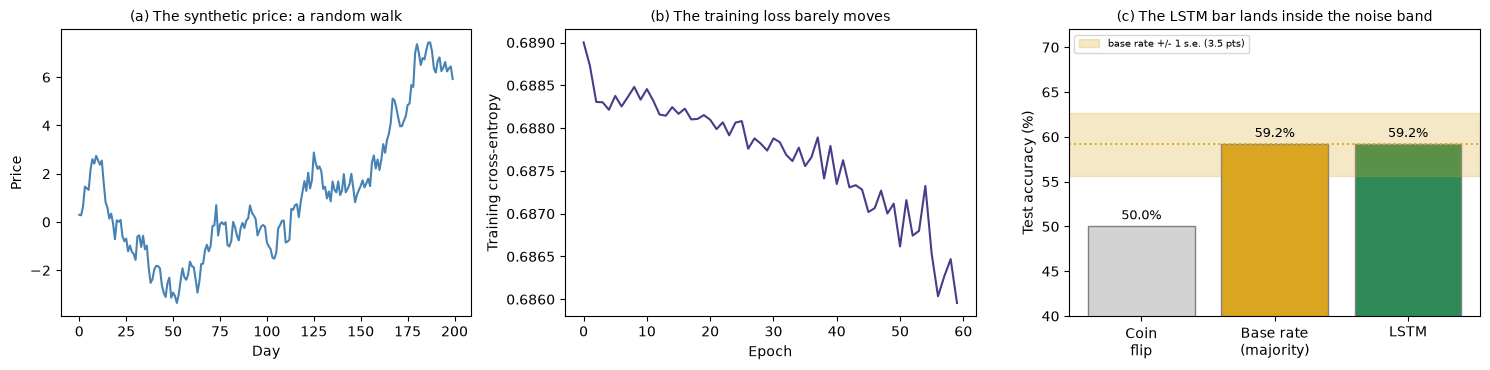

In [8]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

# ── Generate a stock-like price series: a RANDOM WALK with drift ─────────
# Each daily step is independent N(+0.05, 0.5) — the past 20 days carry NO
# information about tomorrow beyond the constant drift.
np.random.seed(42)
torch.manual_seed(0)
n = 1000
price = np.cumsum(np.random.randn(n) * 0.5 + 0.05).astype(np.float32)

# Create sequences: use 20 days to predict direction on day 21
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(price) - SEQ_LEN - 1):
    X_list.append(price[i:i+SEQ_LEN])
    y_list.append(1 if price[i+SEQ_LEN] > price[i+SEQ_LEN-1] else 0)

X_arr = np.array(X_list); y_arr = np.array(y_list)
# Normalise each sequence
X_arr = (X_arr - X_arr.mean(1,keepdims=True)) / (X_arr.std(1,keepdims=True)+1e-8)

split = int(0.8*len(X_arr))
Xtr = torch.tensor(X_arr[:split]).unsqueeze(-1)  # (N, 20, 1)
Ytr = torch.tensor(y_arr[:split], dtype=torch.long)
Xte = torch.tensor(X_arr[split:]).unsqueeze(-1)
Yte = torch.tensor(y_arr[split:], dtype=torch.long)

# ── LSTM Model ──────────────────────────────────────────────────────
class TrendLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True, num_layers=2, dropout=0.2)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # last time step

model   = TrendLSTM()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(60):
    model.train()
    loss = loss_fn(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

# ── Honest evaluation: compare against the base rate, not against 50% ─────
model.eval()
with torch.no_grad():
    pred = model(Xte).argmax(1)
acc = (pred == Yte).float().mean().item()
frac_up = pred.float().mean().item()
p_up = Yte.float().mean().item()
base = max(p_up, 1.0 - p_up)   # always predict the majority direction

se = 100.0 * np.sqrt(base * (1 - base) / len(Yte))   # 1 standard error on a test set this small
print(f"LSTM direction accuracy:          {acc*100:.1f}%")
print(f"Always-predict-majority baseline: {base*100:.1f}%  (test set is {p_up*100:.1f}% 'up' days)")
print(f"LSTM edge over the honest baseline: {(acc-base)*100:+.1f} points")
print(f"The trained LSTM answers 'up' on {frac_up*100:.0f}% of test days.")
print()
print("By construction, each day's move is INDEPENDENT of the past 20 days,")
print("so no model can consistently beat the base rate on this data - any gap")
print(f"either way is test-set noise (1 standard error is +/-{se:.1f} points at n={len(Yte)}).")
print("Lesson: always compare a 'market predictor' to the base rate, not to 50%.")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(price[:200], color="steelblue")
axes[0].set_title("(a) The synthetic price: a random walk", fontsize=10)
axes[0].set_xlabel("Day"); axes[0].set_ylabel("Price")

axes[1].plot(losses, color="darkslateblue")
axes[1].set_title("(b) The training loss barely moves", fontsize=10)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Training cross-entropy")

labels = ["Coin\nflip", "Base rate\n(majority)", "LSTM"]
vals = [50.0, base * 100, acc * 100]
bars = axes[2].bar(labels, vals, color=["lightgrey", "goldenrod", "seagreen"], edgecolor="grey")
axes[2].bar_label(bars, fmt="%.1f%%", fontsize=9, padding=3)
axes[2].axhspan(base * 100 - se, base * 100 + se, color="goldenrod", alpha=0.25,
                label=f"base rate +/- 1 s.e. ({se:.1f} pts)")
axes[2].axhline(base * 100, color="goldenrod", ls=":", lw=1.4)
axes[2].set_ylim(40, 72)
axes[2].set_ylabel("Test accuracy (%)")
axes[2].set_title("(c) The LSTM bar lands inside the noise band", fontsize=10)
axes[2].legend(fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()

### 👁️ Read the figure

- **(a)** The price wanders. It has an upward tilt (the drift we built in) and no repeating structure, because every daily step was drawn independently of the past.
- **(b)** The loss does fall — the optimiser works — but **read the y-axis**: it moves by about 0.003 of cross-entropy in 60 epochs. A falling loss curve proves the plumbing, never the result.
- **(c)** Against a coin flip (grey) the LSTM looks like a winner. Against the base rate — the golden line, "always say up" — the green bar tops out at the same height, **inside the shaded band** of ordinary test-set noise. The printed line above says why they match to the decimal: the network answers "up" on essentially every test day. All those gates, and it has rediscovered the one-word rule. On structureless data that is the only correct outcome.

## 🧩 Mini-exercise

**Try it:** Replace the LSTM with a GRU layer (same number of units), retrain for 1 epoch, and compare the loss curve with the LSTM run.

---

## ✅ Summary

**What you did:** Built an LSTM for sequence classification (IMDB sentiment), trained it, and plotted loss/accuracy.

**In real life you'd also:** Try GRU, bidirectional LSTM, and tune units and embedding size.

**The main idea:** LSTM uses gates to control memory and helps train on longer sequences; it often outperforms SimpleRNN on long-range dependencies.

**Next:** `04_transformer_attention` introduces attention and transformers; `06_gpt_text_generation` covers text generation.

## 🔭 State of the field (2026)

For language, LSTMs and GRUs were replaced in production by transformers years ago. What changed in 2024 is that the gates themselves came back under revision rather than being retired. xLSTM (arXiv 2405.04517) replaces the LSTM's sigmoid gating with *exponential* gating plus a normaliser state, and its mLSTM variant drops the hidden-to-hidden recurrence for a matrix memory that parallelises — scaled to billions of parameters and reported competitive with transformers and state-space models. *Were RNNs All We Needed?* (arXiv 2410.01201) goes the other way and deletes structure: minimal LSTM/GRU variants whose gates no longer depend on the previous hidden state, which makes training fully parallel.

**Why the classic gates are still the right thing to learn.** Both of those papers are *diffs* against the forget/input/output equations in this notebook — you cannot evaluate either claim without them. The gating idea itself also outlived the architecture: gated residual paths and selective state updates appear throughout modern sequence models. And constant memory per step, the property that makes recurrence attractive again for long context, is a property of the cell state you are studying here.


## 📚 References

1. Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation 9(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735
2. Cho, K. et al. (2014). *Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation* (GRU). EMNLP. https://arxiv.org/abs/1406.1078
3. Greff, K. et al. (2017). *LSTM: A Search Space Odyssey*. IEEE Transactions on Neural Networks and Learning Systems. https://arxiv.org/abs/1503.04069

**Recent work (2024–2026)**

4. Beck, M. et al. (2024). *xLSTM: Extended Long Short-Term Memory*. arXiv. https://arxiv.org/abs/2405.04517 — the 2024 rebuild of the exact gates in this notebook: exponential gating with a normaliser state (sLSTM) and a matrix memory that parallelises (mLSTM).
5. Feng, L., Tung, F., Ahmed, M. O., Bengio, Y. & Hajimirsadeghi, H. (2024). *Were RNNs All We Needed?* arXiv. https://arxiv.org/abs/2410.01201 — strips the gates' dependence on the previous hidden state so training parallelises, with fewer parameters than the LSTM/GRU you just built.
